# Earth Observation with EuroSAT and an MLP

Notebook 07 used Fashion-MNIST to introduce the real-data workflow: `Dataset` + `DataLoader`, normalization, three-way split, single test-set evaluation, multi-seed confirmation. This is a parallel notebook that swaps the dataset for something scientific: **EuroSAT**, a Sentinel-2 satellite imagery benchmark.

EuroSAT contains 27,000 RGB images at 64x64 resolution, organized into 10 land-use / land-cover classes (Forest, River, Highway, Industrial, AnnualCrop, ...). The task is real and operationally useful — automated land-cover mapping from satellite imagery is how organizations like the European Space Agency monitor deforestation, urbanization, and crop health at continent scale.

The architecture is still an MLP. The point is to see how the methodology of notebook 07 transfers to a non-medical scientific dataset with a different shape (RGB, larger images, no canonical val/test split) and to set up the motivation for convolutional networks in notebook 08.

## Learning goals

By the end of this notebook you should be able to explain:

1. how the same training harness from notebook 07 generalizes to RGB inputs and a dataset without a canonical val/test split,
2. why EuroSAT's per-channel mean/std differ from MNIST-family constants, and how to compute them yourself,
3. how to carve a stratification-free three-way split with `random_split`,
4. why a plain MLP is a *poor* match for satellite imagery and how that shows up in the confusion matrix,
5. where the per-class errors concentrate (Highway vs Residential, AnnualCrop vs PermanentCrop) and why.

In [ ]:
import math
import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

seed = 11
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

torch.set_default_dtype(torch.float32)

plt.rcParams.update({
    "figure.figsize": (7.4, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Check for GPU availability and set the device accordingly
if torch.cuda.is_available():
    device = torch.device("cuda:1" if torch.cuda.device_count() >= 2 else "cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Apple Silicon GPU
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if device.type == "cuda":
    print("CUDA devices:", torch.cuda.device_count())
    print("Selected GPU:", torch.cuda.get_device_name(device))

PyTorch version: 2.5.1
Device: mps


## Loading EuroSAT, and carving our own three-way split

Unlike MNIST or Fashion-MNIST, **EuroSAT does not ship with a canonical train/test split** — torchvision gives us a single 27,000-image collection and leaves it to us to partition. That is actually the common case for scientific datasets, so it is worth practicing.

We use `random_split` with a fixed generator seed to carve approximately 80% train, 10% validation, 10% test. The split is *not* stratified by class, which is fine here because EuroSAT is roughly class-balanced (2,000-3,000 images per class). On more skewed datasets you would want a stratified split — `sklearn.model_selection.train_test_split` with `stratify=labels` is one easy way.

In [14]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

# Published per-channel statistics for EuroSAT RGB (computed on the full dataset
# in 0..1 float range). You can verify these by computing them yourself on the
# raw dataset, before normalization, as a useful exercise.
EUROSAT_MEAN = (0.3444, 0.3803, 0.4078)
EUROSAT_STD  = (0.2037, 0.1366, 0.1148)

transform = transforms.Compose([
    transforms.ToTensor(),  # uint8 [0,255] -> float32 [0,1], shape (3, 64, 64)
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD),
])

full_dataset = torchvision.datasets.EuroSAT(DATA_DIR, download=True, transform=transform)

n_total = len(full_dataset)
n_test = int(0.10 * n_total)
n_val  = int(0.10 * n_total)
n_train = n_total - n_val - n_test

split_generator = torch.Generator().manual_seed(42)
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test], generator=split_generator,
)

# torchvision derives class names from folder names; cache them for plotting later.
CLASS_NAMES = full_dataset.classes

print(f"Total:  {n_total}")
print(f"Train:  {len(train_set):>5d}")
print(f"Val:    {len(val_set):>5d}")
print(f"Test:   {len(test_set):>5d}")
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

Total:  27000
Train:  21600
Val:     2700
Test:    2700
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


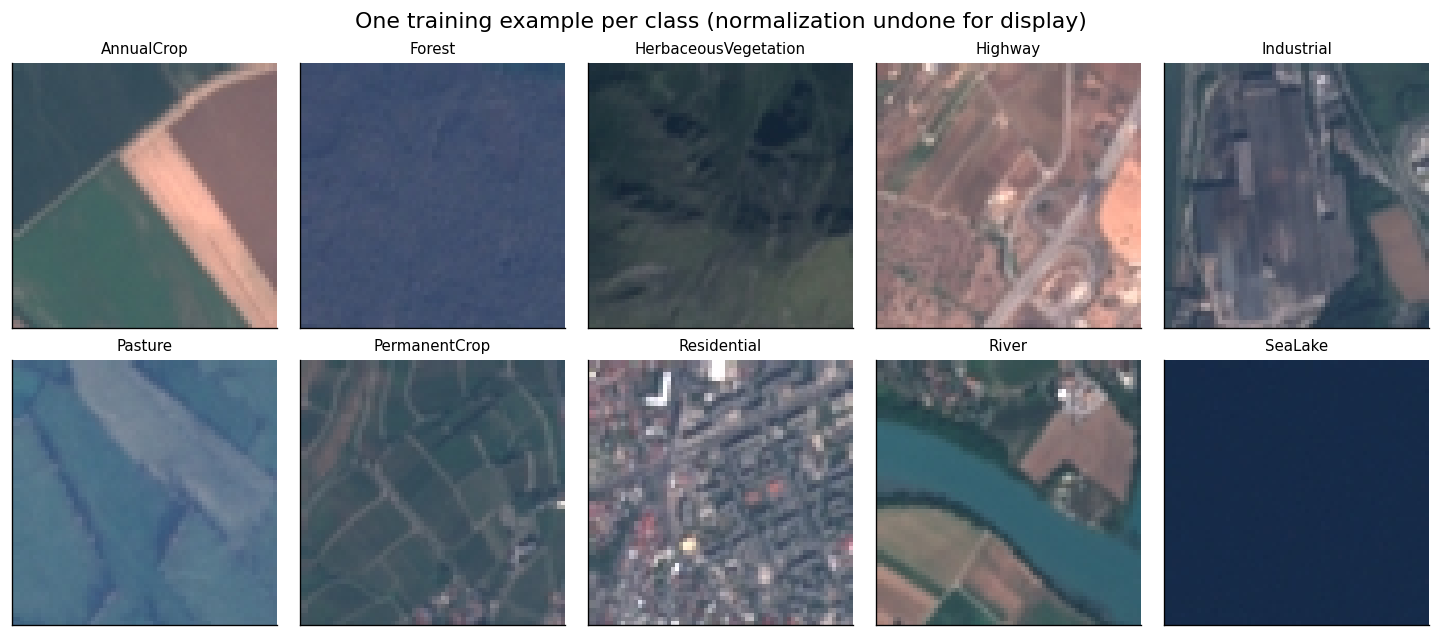

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5.2), constrained_layout=True)
# Pick one image per class for a balanced overview
shown_per_class = {i: None for i in range(len(CLASS_NAMES))}
for image, label in train_set:
    if shown_per_class[label] is None:
        shown_per_class[label] = image
    if all(v is not None for v in shown_per_class.values()):
        break

mean_t = torch.tensor(EUROSAT_MEAN).view(3, 1, 1)
std_t  = torch.tensor(EUROSAT_STD).view(3, 1, 1)

for class_idx, ax in enumerate(axes.flat):
    img = shown_per_class[class_idx]
    display = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(display)
    ax.set_title(CLASS_NAMES[class_idx], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
fig.suptitle("One training example per class (normalization undone for display)")
plt.show()

## `DataLoader` setup

Same machinery as notebook 07. EuroSAT images are larger (3x64x64 = 12,288 floats per sample vs 784 for Fashion-MNIST) so a single batch carries about 16x more data, but at this scale and batch size CPU is still fine.

In [16]:
BATCH_SIZE = 128

loader_generator = torch.Generator().manual_seed(2025)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"xb shape: {tuple(xb.shape)}")
print(f"yb shape: {tuple(yb.shape)}")
print(f"xb mean/std (after normalization): {xb.mean().item():.3f} / {xb.std().item():.3f}")

xb shape: (128, 3, 64, 64)
yb shape: (128,)
xb mean/std (after normalization): 0.031 / 1.086


## The MLP

We flatten the 3x64x64 input to a 12,288-vector and feed it through two hidden layers with ReLU activations. The model has roughly 3.3M parameters — most of them in the first `Linear(12288, 256)` layer — which is large compared with the 21,600 training images. This **parameter-to-data ratio** is a built-in invitation to overfit; early stopping is what saves us, and it is one of the reasons CNNs (which weight-share across spatial positions) make so much more sense here.

We also add **dropout** after each ReLU as an additional regularizer. During training, dropout randomly zeros out a fraction `p` of activations on each forward pass, which prevents any single feature from being relied on too heavily and effectively trains an ensemble of subnetworks. At evaluation time the layer is a no-op (PyTorch handles the train/eval switch automatically based on `model.train()` / `model.eval()`, which our training harness already does). We use `p=0.3` as a sensible default for this size of network; set `dropout=0.0` to disable.

In [17]:
INPUT_DIM = 3 * 64 * 64

def make_mlp(seed, hidden=(256, 128), num_classes=10, input_dim=INPUT_DIM, dropout=0.3):
    torch.manual_seed(seed)
    layers = [nn.Flatten()]
    in_dim = input_dim
    for h in hidden:
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        if dropout > 0:
            layers += [nn.Dropout(p=dropout)]
        in_dim = h
    layers += [nn.Linear(in_dim, num_classes)]
    return nn.Sequential(*layers)

demo_model = make_mlp(seed=123)
n_params = sum(p.numel() for p in demo_model.parameters() if p.requires_grad)
print(demo_model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Training examples:    {len(train_set):,}")
print(f"Params per example:   {n_params / len(train_set):.1f}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=128, out_features=10, bias=True)
)

Trainable parameters: 3,180,170
Training examples:    21,600
Params per example:   147.2


## Training function

Identical to notebook 07's `train_with_loaders`. The whole point of having a clean training harness is that swapping the dataset doesn't change it.

In [18]:
def evaluate_loader(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += loss_fn(logits, yb).item() * xb.size(0)
            total_correct += (logits.argmax(-1) == yb).sum().item()
            total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n


def train_with_loaders(
    optimizer_factory,
    train_loader, val_loader,
    *,
    max_epochs=30,
    patience=5,
    min_delta=1e-4,
    model_seed=123,
    device=device,
    verbose=True,
):
    """Train an MLP with early stopping on validation loss. Returns model + history + best checkpoint."""
    model = make_mlp(model_seed).to(device)
    optimizer = optimizer_factory(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best = {"val_loss": float("inf"), "val_acc": None, "epoch": 0, "state_dict": None}
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(-1) == yb).sum().item()
            running_n += xb.size(0)
        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        val_loss, val_acc = evaluate_loader(model, val_loader, loss_fn, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best["val_loss"] - min_delta:
            best.update({
                "val_loss": val_loss, "val_acc": val_acc, "epoch": epoch,
                "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            })
            epochs_no_improve = 0
            marker = "*"
        else:
            epochs_no_improve += 1
            marker = " "

        if verbose:
            print(f"epoch {epoch:3d} {marker} | train loss {train_loss:.3f} acc {train_acc:.3f} | val loss {val_loss:.3f} acc {val_acc:.3f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs)")
            break

    if best["state_dict"] is not None:
        model.load_state_dict(best["state_dict"])
    return model, history, best

In [ ]:
# Training configuration — set once here and reused by both the baseline run
# and the multi-seed sweep below, so they are guaranteed to be comparable.
TRAIN_LR = 3e-4
TRAIN_MAX_EPOCHS = 60
TRAIN_PATIENCE = 10

## Baseline training run

**AdamW** at `lr=3e-4` (lower than the universal `1e-3` default — better for an MLP with this many parameters), early stopping with `patience=10` on a `max_epochs=60` budget. The configuration constants are defined once in the cell above so the multi-seed sweep further down uses the same settings. We do not expect this to be competitive with state-of-the-art (small CNNs reach ~98% on EuroSAT), but it gives us a baseline number and a confusion matrix to interpret.

In [ ]:
def adamw_factory(lr, weight_decay=0.01):
    return lambda params: torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

model, history, best = train_with_loaders(
    adamw_factory(lr=TRAIN_LR),
    train_loader, val_loader,
    max_epochs=TRAIN_MAX_EPOCHS, patience=TRAIN_PATIENCE,
    model_seed=123,
)

print()
print(f"Best epoch:        {best['epoch']}")
print(f"Best val loss:     {best['val_loss']:.4f}")
print(f"Best val accuracy: {best['val_acc']:.4f}")

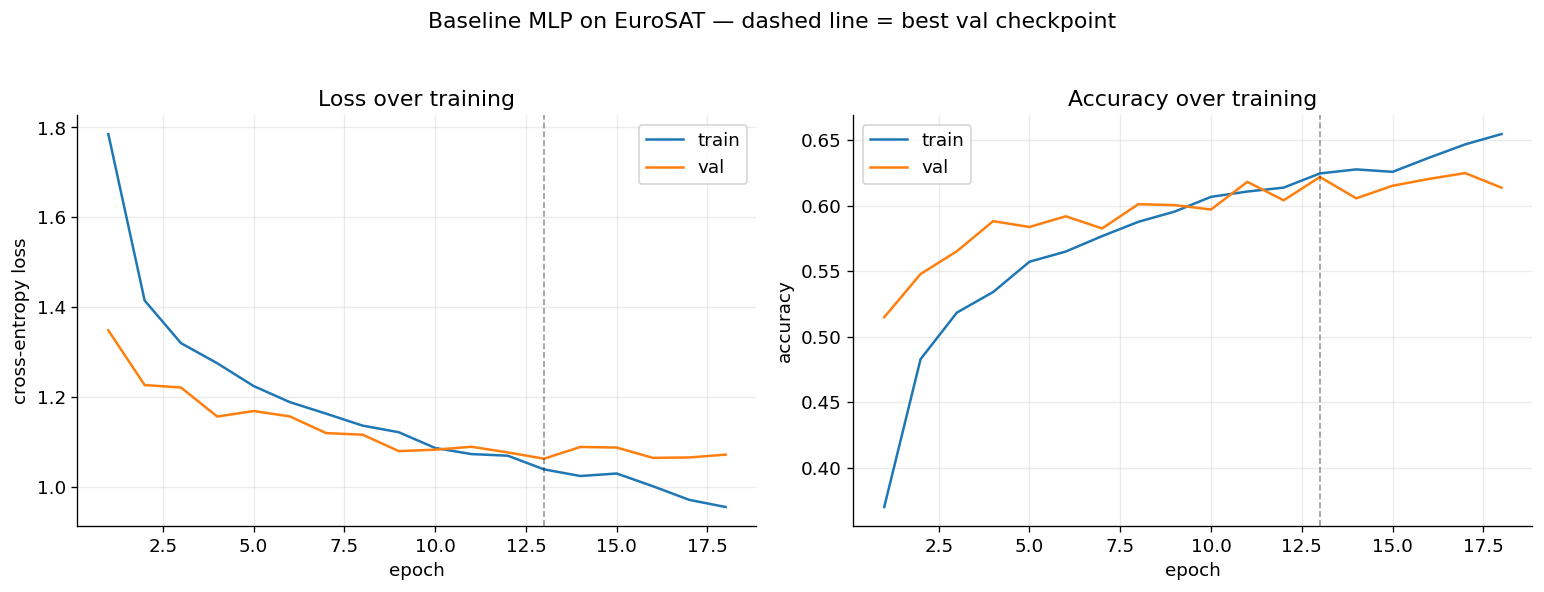

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["val_loss"],   label="val")
axes[0].axvline(best["epoch"], linestyle="--", linewidth=1, alpha=0.4, color="black")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Loss over training")
axes[0].legend(loc="best")

axes[1].plot(history["epoch"], history["train_acc"], label="train")
axes[1].plot(history["epoch"], history["val_acc"],   label="val")
axes[1].axvline(best["epoch"], linestyle="--", linewidth=1, alpha=0.4, color="black")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy over training")
axes[1].legend(loc="best")
fig.suptitle("Baseline MLP on EuroSAT — dashed line = best val checkpoint")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Final test-set evaluation

Same discipline as notebook 07: touch the test set **once**, after model selection on the validation set is finished.

In [26]:
test_loss, test_acc = evaluate_loader(model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print()
print("For comparison:")
print(f"  Best val loss: {best['val_loss']:.4f}")
print(f"  Best val acc:  {best['val_acc']:.4f}")

Test loss:     1.0626
Test accuracy: 0.6330

For comparison:
  Best val loss: 1.0190
  Best val acc:  0.6367


## Where do the errors concentrate?

EuroSAT has known semantic neighbors that are hard to distinguish from any pixel-wise classifier:

- **AnnualCrop / PermanentCrop / Pasture / HerbaceousVegetation** — all dominated by green textures.
- **Highway / Residential / Industrial** — all built-up surfaces with grey/asphalt tones.
- **River / SeaLake** — both water, distinguished mostly by shape (linear vs blob).

A plain MLP throws away spatial structure, so the *shape* distinctions in particular (River vs SeaLake, Highway vs Industrial) are exactly where it should fail. Watch for that in the confusion matrix below.

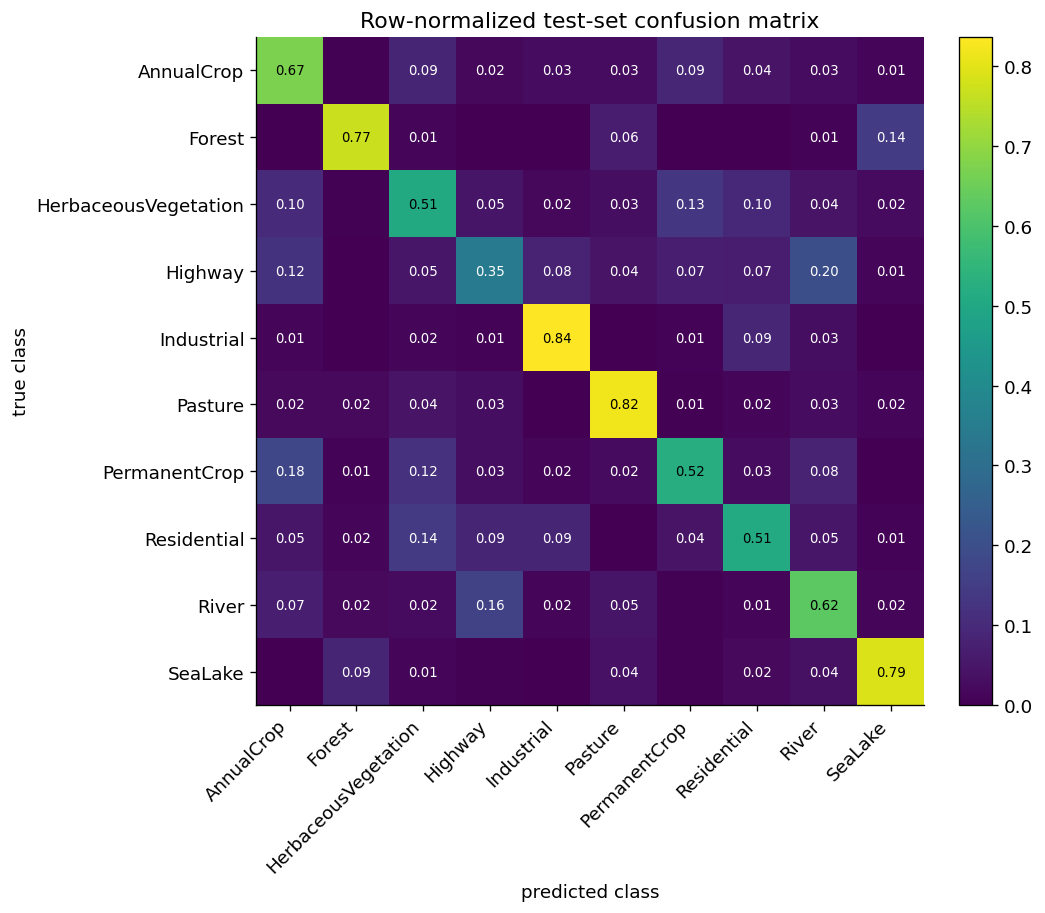

In [27]:
def confusion_matrix(model, loader, num_classes, device):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(-1)
            for t, p in zip(yb.cpu(), preds.cpu()):
                cm[t, p] += 1
    return cm

cm = confusion_matrix(model, test_loader, num_classes=len(CLASS_NAMES), device=device)
cm_row_norm = cm.float() / cm.sum(dim=1, keepdim=True).clamp_min(1)

fig, ax = plt.subplots(figsize=(9.0, 7.5), constrained_layout=True)
im = ax.imshow(cm_row_norm.numpy(), cmap="viridis")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("predicted class")
ax.set_ylabel("true class")
ax.set_title("Row-normalized test-set confusion matrix")
ax.grid(False)
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        val = cm_row_norm[i, j].item()
        if val < 0.005:
            continue
        color = "white" if val < 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)
plt.show()

## A look at misclassified test examples

A handful of failures, displayed in RGB (with normalization undone).

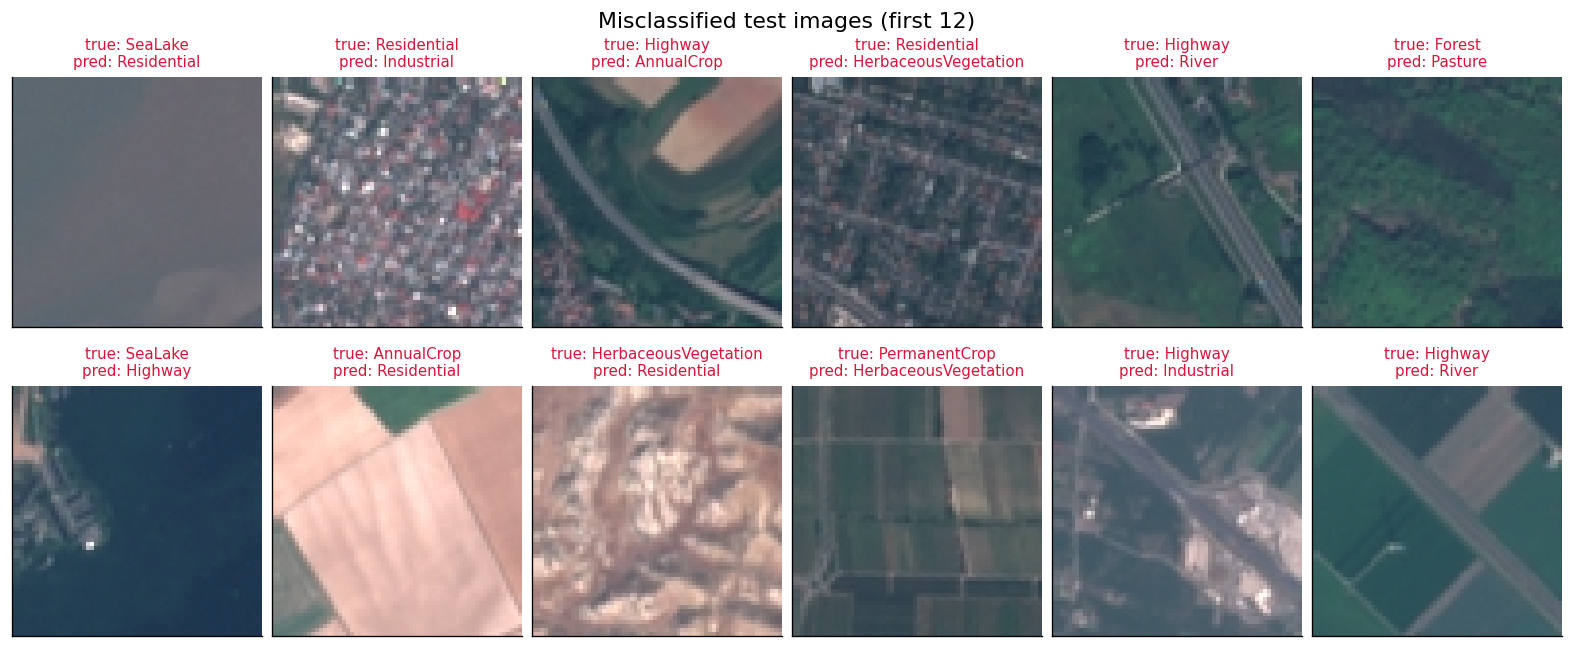

In [28]:
model.eval()
misclassified = []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(-1).cpu()
        for img, true, pred in zip(xb, yb, preds):
            if pred.item() != true.item():
                misclassified.append((img, true.item(), pred.item()))
                if len(misclassified) >= 12:
                    break
        if len(misclassified) >= 12:
            break

fig, axes = plt.subplots(2, 6, figsize=(13, 5.4), constrained_layout=True)
for ax, (img, true, pred) in zip(axes.flat, misclassified):
    display = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(display)
    ax.set_title(f"true: {CLASS_NAMES[true]}\npred: {CLASS_NAMES[pred]}", fontsize=9, color="crimson")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
fig.suptitle("Misclassified test images (first 12)")
plt.show()

## Multi-seed confirmation

Three seeds for the same reason as notebook 07: a single accuracy number can move a percentage point or two between seeds. Each EuroSAT run is more expensive than a Fashion-MNIST run (larger images), so three is a reasonable budget on CPU; raise it if you have a GPU.

In [ ]:
repeat_seeds = [123, 234, 345]

val_losses, val_accs, test_accs = [], [], []
for ms in repeat_seeds:
    print(f"\n=== seed {ms} ===")
    m, h, b = train_with_loaders(
        adamw_factory(lr=TRAIN_LR),
        train_loader, val_loader,
        max_epochs=TRAIN_MAX_EPOCHS, patience=TRAIN_PATIENCE,
        model_seed=ms,
        verbose=False,
    )
    t_loss, t_acc = evaluate_loader(m, test_loader, nn.CrossEntropyLoss(), device)
    val_losses.append(b["val_loss"])
    val_accs.append(b["val_acc"])
    test_accs.append(t_acc)
    print(f"  best val loss {b['val_loss']:.4f}, val acc {b['val_acc']:.4f}, test acc {t_acc:.4f} (best epoch {b['epoch']})")

print()
print(f"val loss across seeds:      {np.mean(val_losses):.4f} +/- {np.std(val_losses):.4f}")
print(f"val accuracy across seeds:  {np.mean(val_accs):.4f} +/- {np.std(val_accs):.4f}")
print(f"test accuracy across seeds: {np.mean(test_accs):.4f} +/- {np.std(test_accs):.4f}")

## Summary

What changed from notebook 07:

| Change                          | Why                                                                     |
|---------------------------------|-------------------------------------------------------------------------|
| Three-way split via `random_split` | EuroSAT has no canonical val/test split, so we partition ourselves.    |
| RGB normalization constants     | Different mean/std per channel; satellite imagery has its own statistics. |
| 64x64x3 input (12,288 features) | Flatten-then-MLP becomes very parameter-heavy on real images.           |
| RGB display in plots            | Drop `cmap="gray"`, denormalize all three channels.                     |

What stayed the same — and is the point:

- `DataLoader` workflow,
- early stopping on validation loss with best-checkpoint restore,
- single touch of the test set,
- multi-seed confirmation.

**Result interpretation.** An MLP on EuroSAT typically lands around 75-82% test accuracy. State-of-the-art CNN baselines reach ~98%. The gap is much larger than on Fashion-MNIST (where MLP ~89%, small CNN ~92%) — because satellite imagery is dominated by *spatial* features (linear road structure, river shape, urban grid patterns) that a fully-connected network can only learn by memorizing pixel positions. This is exactly what convolutions are designed to handle.

Notebook 08 picks up here with a CNN.

## Exercises

1. **Compute the normalization constants yourself.** Load the unnormalized dataset (drop the `Normalize` step), iterate over the training split, and compute the per-channel mean and std. How close are your numbers to the published constants above?

2. **Stratified split.** Replace the `random_split` with a stratified split (e.g. via `sklearn.model_selection.train_test_split` with `stratify=labels`). Does the per-class accuracy in the confusion matrix become more even?

3. **Bigger MLP.** Try `hidden=(1024, 512, 256)`. Does adding capacity help, or does it just overfit faster?

4. **Downsample to 32x32.** Add `transforms.Resize(32)` before `ToTensor`. How much accuracy do you lose, and how much does training speed up?

5. **Augmentation.** Add `transforms.RandomHorizontalFlip()` and `transforms.RandomRotation(15)` to the training transform only (not val/test). Does augmentation help an MLP much? (Spoiler: not as much as it will help a CNN.)

6. **Optimizer swap.** Compare AdamW with SGD+momentum (`lr=0.05`, `momentum=0.9`) + cosine schedule. Does the notebook 06 ranking still hold on real imagery?